In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

/tmp/ipykernel_16/2549451149.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


In [3]:
print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

train shape: (138701, 50)
test shape: (15000, 49)


In [4]:
train.sample(10)

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
108545,2415112,39000.0,1473251,471,CEA153,UJF,2000,0.0,NaN,2008-07-19,...,Steel,None or Unspecified,"10' 6""",Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
1531,1147259,64000.0,6344,3856,ACH138,GTX,1999,10850.0,Medium,2007-05-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
107763,2412761,55000.0,1137992,16702,CEA153,UJF,2004,0.0,NaN,2008-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
106449,2404263,23500.0,1570215,348,CEA153,EVS,1998,0.0,NaN,2009-04-02,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
132385,4364149,57500.0,2310764,28927,IHB189,UJF,2008,6114.0,High,2012-11-15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
64538,1721725,30000.0,1177636,11876,ADI149,UJF,1001,NaN,NaN,2009-02-22,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
66435,1731598,38000.0,1554178,503,ADI149,UJF,1987,NaN,NaN,1995-09-20,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Triple,NaN,NaN,NaN,NaN
40905,1521885,17000.0,1298545,4210,ADI149,MPF,1989,NaN,NaN,1999-06-13,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
133719,4394497,30000.0,2273913,22860,IHB189,UJF,2008,1477.0,Low,2013-02-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
34406,1462957,38000.0,1099785,1692,ADI149,RZI,1990,NaN,NaN,1996-12-07,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [6]:
transaction_ids = test['TransactionID']
transaction_ids

0        1139307
1        1139419
2        1139482
3        1139522
4        1139684
          ...   
14995    6333296
14996    6333344
14997    6333356
14998    6333364
14999    6333397
Name: TransactionID, Length: 15000, dtype: int64

In [7]:
train = train.drop('TransactionID', axis=1)
test = test.drop('TransactionID', axis=1)

In [8]:
round((train.isnull().sum().sort_values(ascending=False)/train.shape[0])*100,2)

col18                        99.95
col19                        99.95
col4                         92.52
col5                         92.52
col28                        89.21
col27                        89.21
col30                        86.39
col29                        86.39
col14                        83.13
col7                         83.13
col6                         83.13
col9                         83.13
col8                         83.13
col13                        83.13
col11                        83.13
col3                         78.91
Forks                        78.86
Spec_ReleaseSeries           76.28
col1                         75.64
col12                        72.34
col15                        69.52
DrivetrainType               64.86
UtilizationTier              63.61
Spec_VariantModifier         62.27
col25                        48.80
col20                        48.80
col21                        48.80
col22                        48.80
col24               

In [9]:
high_missing_values_cols = [
    'col18', 'col19', 'col4' , 'col5' , 'col28',
    'col27' , 'col30' , 'col14', 'col7', 'col29',
    'col6', 'col9' , 'col8' , 'col13' , 'col11',
]

In [10]:
train = train.drop(high_missing_values_cols, axis=1)
test = test.drop(high_missing_values_cols, axis=1)

In [11]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])
test["TransactionDate"] = pd.to_datetime(test["TransactionDate"])

train["TransactionYear"] = train["TransactionDate"].dt.year
test["TransactionYear"] = test["TransactionDate"].dt.year

train["TransactionMonth"] = train["TransactionDate"].dt.month
test["TransactionMonth"] = test["TransactionDate"].dt.month

train["TransactionQuarter"] = train["TransactionDate"].dt.quarter
test["TransactionQuarter"] = test["TransactionDate"].dt.quarter

In [12]:
train['AssetAge'] = train['TransactionYear'] - train['ManufactureYear']
test['AssetAge'] = test['TransactionYear'] - test['ManufactureYear']

In [13]:
train['HoursPerYear'] = train['OperationalHoursMeter']/(train['AssetAge'] + 1)
test['HoursPerYear'] = test['OperationalHoursMeter']/(test['AssetAge'] + 1)

<Axes: xlabel='TargetValue', ylabel='Count'>

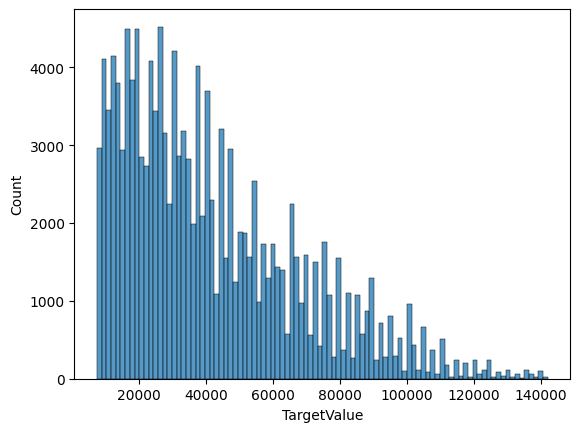

In [14]:
sns.histplot(train["TargetValue"])

<Axes: xlabel='TargetValue', ylabel='Count'>

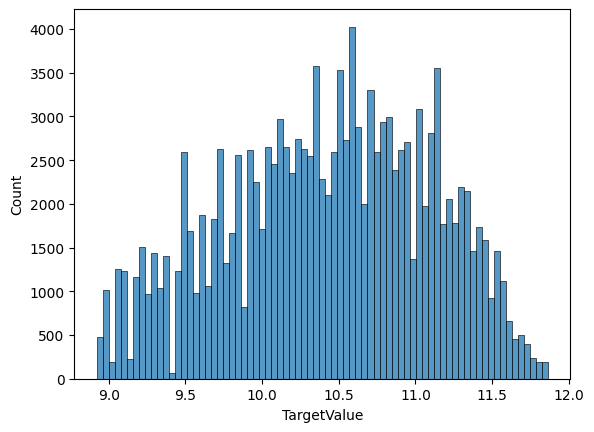

In [15]:
sns.histplot(np.log1p(train["TargetValue"]))

In [16]:
train['TargetValue'] = np.log1p(train['TargetValue'])

<Axes: >

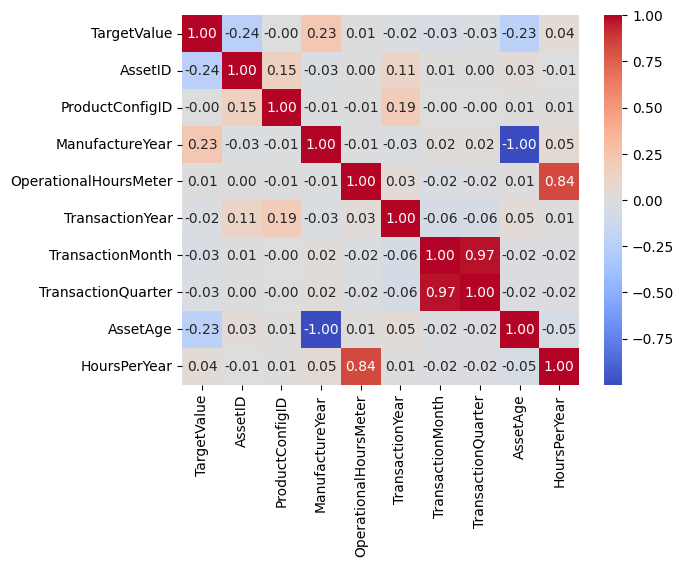

In [17]:
sns.heatmap(train.corr(numeric_only=True), annot=True , cmap='coolwarm', fmt='.2f')

In [18]:
y = train["TargetValue"]

X = train.drop(columns=["TargetValue"])

In [19]:
X = X.drop(columns=["AssetID"])
X["ProductConfigID"] = X["ProductConfigID"].astype(str)

In [20]:
cat_cols = X.select_dtypes(include="object").columns

X[cat_cols] = X[cat_cols].fillna("Missing")

In [21]:
num_cols = X.select_dtypes(
    include=["int64", "int32", "float64"]
).columns

X[num_cols] = X[num_cols].fillna(
    X[num_cols].median()
)

In [22]:
X = X.drop(columns=["TransactionDate"])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
y_valid.shape

(27741,)

In [25]:
cat_features = [
    X_train.columns.get_loc(col)
    for col in cat_cols
]

In [26]:
from sklearn.preprocessing import LabelEncoder
X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()

cat_cols = X_train_xgb.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()

    combined = pd.concat([
        X_train_xgb[col].astype(str),
        X_valid_xgb[col].astype(str)
    ])

    le.fit(combined)

    X_train_xgb[col] = le.transform(X_train_xgb[col].astype(str))
    X_valid_xgb[col] = le.transform(X_valid_xgb[col].astype(str))

In [27]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=10,
    enable_categorical=True,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    objective="reg:squarederror",
    random_state=42
)

In [28]:
model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_valid_xgb, y_valid)],
    verbose=100
)

[0]	validation_0-rmse:0.65346
[100]	validation_0-rmse:0.23736
[200]	validation_0-rmse:0.21752
[300]	validation_0-rmse:0.21172
[400]	validation_0-rmse:0.20842
[500]	validation_0-rmse:0.20633
[600]	validation_0-rmse:0.20482
[700]	validation_0-rmse:0.20369
[800]	validation_0-rmse:0.20276
[900]	validation_0-rmse:0.20201
[1000]	validation_0-rmse:0.20155
[1100]	validation_0-rmse:0.20116
[1200]	validation_0-rmse:0.20076
[1300]	validation_0-rmse:0.20052
[1400]	validation_0-rmse:0.20026
[1500]	validation_0-rmse:0.20009
[1600]	validation_0-rmse:0.19992
[1700]	validation_0-rmse:0.19983
[1800]	validation_0-rmse:0.19972
[1900]	validation_0-rmse:0.19968
[2000]	validation_0-rmse:0.19969
[2100]	validation_0-rmse:0.19974
[2200]	validation_0-rmse:0.19971
[2300]	validation_0-rmse:0.19971
[2400]	validation_0-rmse:0.19972
[2500]	validation_0-rmse:0.19974
[2600]	validation_0-rmse:0.19978
[2700]	validation_0-rmse:0.19981
[2800]	validation_0-rmse:0.19984
[2900]	validation_0-rmse:0.19987
[2999]	validation_0-rm

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
from sklearn.metrics import root_mean_squared_log_error

pred_logs = model.predict(X_valid_xgb)

preds = np.expm1(pred_logs)
actual = np.expm1(y_valid)

rmsle = root_mean_squared_log_error(
    actual,
    preds
)

print("RMSLE:", rmsle)

RMSLE: 0.19990532897908733


In [30]:
test = test.copy()

test = test.drop(columns=["AssetID","TransactionDate"])
test["ProductConfigID"] = test["ProductConfigID"].astype(str)

test[cat_cols] = test[cat_cols].fillna("Missing")

test[num_cols] = test[num_cols].fillna(
    X[num_cols].median()
)

In [31]:
final_train_xgb = X.copy()
final_test_xgb = test.copy()

cat_cols = final_train_xgb.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()

    combined = pd.concat([
        final_train_xgb[col].astype(str),
        final_test_xgb[col].astype(str)
    ])

    le.fit(combined)

    final_train_xgb[col] = le.transform(final_train_xgb[col].astype(str))
    final_test_xgb[col] = le.transform(final_test_xgb[col].astype(str))

In [32]:
model.fit(final_train_xgb,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
test_pred_log = model.predict(final_test_xgb)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "TransactionID": transaction_ids,
    "TargetValue": test_pred
})

submission.to_csv('submission.csv', index=False)
submission.shape

(15000, 2)